<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#FashionMNIST" data-toc-modified-id="FashionMNIST-1"><span class="toc-item-num">1&nbsp;&nbsp;</span><b>FashionMNIST</b></a></span></li><li><span><a href="#FashionMNIST" data-toc-modified-id="FashionMNIST-2"><span class="toc-item-num">2&nbsp;&nbsp;</span><b>FashionMNIST</b></a></span></li><li><span><a href="#Данные" data-toc-modified-id="Данные-3"><span class="toc-item-num">3&nbsp;&nbsp;</span><b>Данные</b></a></span></li><li><span><a href="#Задание" data-toc-modified-id="Задание-4"><span class="toc-item-num">4&nbsp;&nbsp;</span><b>Задание</b></a></span></li></ul></div>

---

<h2 style="text-align: center;"><b>FashionMNIST</b></h2>

---

В этом ноутбуке Вам предстоит самостоятельно попрактиковаться в написаноо нейросетей для распознавания датасета, похожего на MNIST, но более интересного -- чёрно-белых изображений одежды.

<h2 style="text-align: center;"><b>FashionMNIST</b></h2>

<img src="https://emiliendupont.github.io/imgs/mnist-chicken/mnist-and-fashion-examples.png">

<h2 style="text-align: center;"><b>Данные</b></h2>

Мы будем работать с картинками одежды (чёрно-белыми, то есть цветовых каналов не 3, а 1). По входной картинке нужно предсказать тип одежды.

In [3]:
# !pip install torchvision

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

In [4]:
trainset = torchvision.datasets.FashionMNIST(root='./data', train=True,
                                        download=True, transform=None)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.FashionMNIST(root='./data', train=False,
                                       download=True, transform=None)
testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)

classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot')

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.77MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.1MB/s]


Каждая картинка имеет класс от 0 до 9, расшифровка меток класса:  

|class_id|class_name|
|----|----|
|0| T-shirt/top|
|1| Trouser|
|2| Pullover|
|3| Dress|
|4| Coat|
|5| Sandal|
|6| Shirt|
|7| Sneaker|
|8| Bag|
|9| Ankle boot|

Посмотрите на датасет.
* Сколько в нём классов?
* Сколько картинок в train? В test?
* Выведите несколько картинок с помощью `pyplot`

Количество классов: 10
Train size: 60000
Test size: 10000


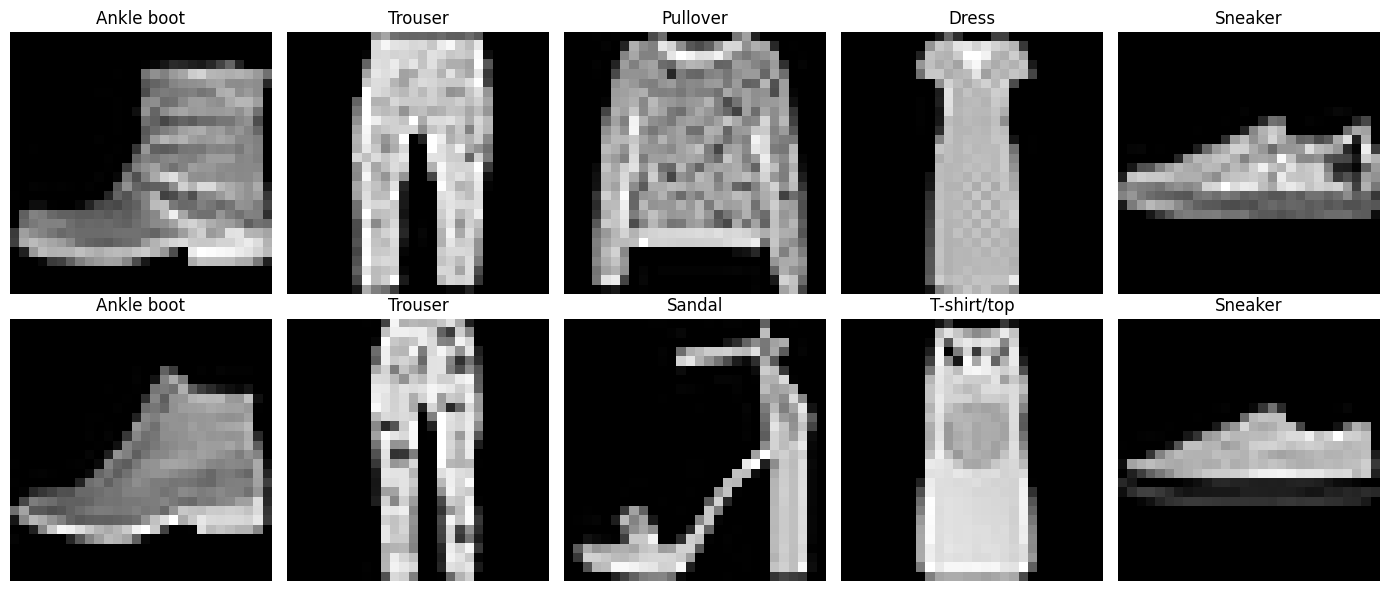

In [5]:
print("Количество классов:", len(classes))
print("Train size:", len(trainset))
print("Test size:", len(testset))


fig, axes = plt.subplots(2, 5, figsize=(14, 6))
indices = np.random.choice(len(trainset), size=10, replace=False)

for ax, idx in zip(axes.flatten(), indices):
    image = trainset.data[idx].numpy()
    label = trainset.targets[idx].item()
    ax.imshow(image, cmap='gray')
    ax.set_title(classes[label])
    ax.axis('off')

plt.tight_layout()

<h2 style="text-align: center;"><b>Задание</b></h2>

Используя материалы семинаров по многослойным  и свёрточным сетям, напишите Свёрточную сеть, классифицирующую этот датасет.
Если качество, которое получается у  нейросети, выше 95%, то Вы решили задачу с точностью, которую можно использовать в жизни.

In [7]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms

# фиксируем seed
torch.manual_seed(123)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(123)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# аугментации (чуть изменены)
train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomCrop(28, padding=2),
    transforms.ToTensor(),
    transforms.Normalize((0.28,), (0.35,))
])

test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.28,), (0.35,))
])

# датасеты
train_data = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=train_tf
)

test_data = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=test_tf
)

# загрузчики
BATCH = 128

train_loader = torch.utils.data.DataLoader(
    train_data, batch_size=BATCH, shuffle=True, num_workers=2
)

test_loader = torch.utils.data.DataLoader(
    test_data, batch_size=BATCH, shuffle=False, num_workers=2
)

# модель
class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()

        # сверточная часть
        self.block1 = self._conv_block(1, 64)
        self.block2 = self._conv_block(64, 128)
        self.block3 = self._conv_block(128, 256)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout_small = nn.Dropout(0.1)
        self.dropout_mid = nn.Dropout(0.2)

        # полносвязная часть
        self.classifier = nn.Sequential(
            nn.Linear(256 * 3 * 3, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(128, 10)
        )

    def _conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),

            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU()
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.pool(x)
        x = self.dropout_small(x)

        x = self.block2(x)
        x = self.pool(x)
        x = self.dropout_small(x)

        x = self.block3(x)
        x = self.pool(x)
        x = self.dropout_mid(x)

        x = torch.flatten(x, 1)
        x = self.classifier(x)

        return x


model = ConvNet().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

Device: cuda


In [8]:
import copy

def compute_accuracy(net, data_loader):
    net.eval()
    correct_preds = 0
    total_samples = 0

    with torch.no_grad():
        for x_batch, y_batch in data_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = net(x_batch)
            preds = torch.argmax(outputs, dim=1)

            correct_preds += (preds == y_batch).sum().item()
            total_samples += y_batch.size(0)

    return correct_preds / total_samples


EPOCHS = 40

stats = {
    "loss": [],
    "val_acc": []
}

best_acc = 0.0
best_weights = copy.deepcopy(model.state_dict())
best_models = []

lr_scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1.2e-3,
    epochs=EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.15,
    div_factor=10,
    final_div_factor=100
)

for ep in range(EPOCHS):
    model.train()
    epoch_loss_sum = 0.0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad(set_to_none=True)

        preds = model(x_batch)
        loss = criterion(preds, y_batch)

        loss.backward()
        optimizer.step()
        lr_scheduler.step()

        epoch_loss_sum += loss.item() * y_batch.size(0)

    avg_loss = epoch_loss_sum / len(train_data)
    val_acc = compute_accuracy(model, test_loader)

    # сохраняем лучшую модель
    if val_acc > best_acc:
        best_acc = val_acc
        best_weights = copy.deepcopy(model.state_dict())

    # топ-3 моделей
    best_models.append((val_acc, copy.deepcopy(model.state_dict())))
    best_models = sorted(best_models, key=lambda x: x[0], reverse=True)[:3]

    stats["loss"].append(avg_loss)
    stats["val_acc"].append(val_acc)

    lr_now = optimizer.param_groups[0]["lr"]

    print(f"Epoch {ep+1}/{EPOCHS} | loss={avg_loss:.4f} | acc={val_acc:.4%} | lr={lr_now:.2e}")

    if best_acc >= 0.955:
        print("Достигнута точность >95.5%, ранняя остановка.")
        break

# загружаем лучшие веса
model.load_state_dict(best_weights)

print(f"Best accuracy: {best_acc:.4%}")

Epoch 1/40 | loss=0.7572 | acc=84.9300% | lr=1.92e-04
Epoch 2/40 | loss=0.4016 | acc=87.6800% | lr=3.90e-04
Epoch 3/40 | loss=0.3328 | acc=88.8100% | lr=6.60e-04
Epoch 4/40 | loss=0.2996 | acc=89.8900% | lr=9.30e-04
Epoch 5/40 | loss=0.2752 | acc=88.7000% | lr=1.13e-03
Epoch 6/40 | loss=0.2553 | acc=91.7500% | lr=1.20e-03
Epoch 7/40 | loss=0.2360 | acc=91.7300% | lr=1.20e-03
Epoch 8/40 | loss=0.2225 | acc=92.1200% | lr=1.19e-03
Epoch 9/40 | loss=0.2111 | acc=92.4000% | lr=1.18e-03
Epoch 10/40 | loss=0.1991 | acc=92.2100% | lr=1.16e-03
Epoch 11/40 | loss=0.1891 | acc=93.1200% | lr=1.14e-03
Epoch 12/40 | loss=0.1867 | acc=93.2300% | lr=1.11e-03
Epoch 13/40 | loss=0.1776 | acc=93.3100% | lr=1.08e-03
Epoch 14/40 | loss=0.1695 | acc=93.7200% | lr=1.04e-03
Epoch 15/40 | loss=0.1650 | acc=93.8600% | lr=1.00e-03
Epoch 16/40 | loss=0.1586 | acc=93.5200% | lr=9.62e-04
Epoch 17/40 | loss=0.1488 | acc=93.1900% | lr=9.16e-04
Epoch 18/40 | loss=0.1435 | acc=93.9300% | lr=8.68e-04
Epoch 19/40 | loss=

Single model accuracy: 95.3800%
Ensemble accuracy: 95.3300%
Chosen: single model
Final accuracy: 95.3800%
T-shirt/top : 91.00%
Trouser     : 99.30%
Pullover    : 92.40%
Dress       : 95.80%
Coat        : 95.20%
Sandal      : 98.70%
Shirt       : 86.20%
Sneaker     : 98.30%
Bag         : 99.60%
Ankle boot  : 97.30%


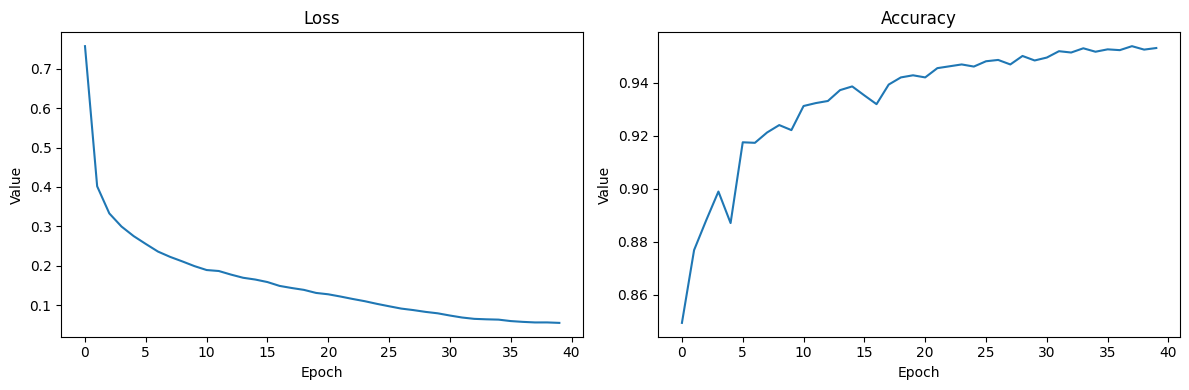

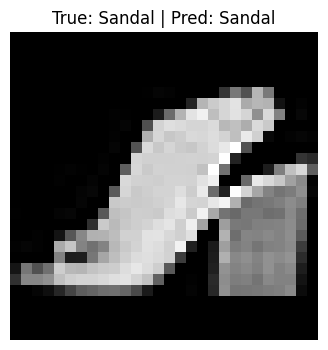

In [9]:
# собираем ансамбль из лучших моделей
ensemble_list = []

for _, weights in best_models:
    m = ConvNet().to(device)
    m.load_state_dict(weights)
    m.eval()
    ensemble_list.append(m)


def ensemble_forward(x):
    sum_logits = 0
    for m in ensemble_list:
        sum_logits += m(x)
    return sum_logits / len(ensemble_list)


def evaluate_model(predict_function):
    per_class_correct = [0] * len(classes)
    per_class_total = [0] * len(classes)

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            preds = predict_function(x_batch).argmax(dim=1)

            for y_true, y_pred in zip(y_batch.cpu(), preds.cpu()):
                per_class_total[y_true.item()] += 1
                per_class_correct[y_true.item()] += int(y_true.item() == y_pred.item())

    total_acc = sum(per_class_correct) / sum(per_class_total)
    return total_acc, per_class_correct, per_class_total


# accuracy одиночной модели
single_acc, single_corr, single_tot = evaluate_model(lambda x: model(x))

# accuracy ансамбля
ensemble_acc, ens_corr, ens_tot = evaluate_model(ensemble_forward)

print(f"Single model accuracy: {single_acc:.4%}")
print(f"Ensemble accuracy: {ensemble_acc:.4%}")


# выбор лучшего варианта
if ensemble_acc >= single_acc:
    final_acc = ensemble_acc
    final_corr = ens_corr
    final_tot = ens_tot
    predict_fn = ensemble_forward
    chosen = "ensemble"
else:
    final_acc = single_acc
    final_corr = single_corr
    final_tot = single_tot
    predict_fn = lambda x: model(x)
    chosen = "single model"

print(f"Chosen: {chosen}")
print(f"Final accuracy: {final_acc:.4%}")


# accuracy по классам
for i, name in enumerate(classes):
    print(f"{name:12s}: {final_corr[i] / final_tot[i]:.2%}")


# графики
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(stats["loss"])
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Value")

plt.subplot(1, 2, 2)
plt.plot(stats["val_acc"])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Value")

plt.tight_layout()


# визуализация одного примера
def show_prediction(idx):
    raw_img = test_data.data[idx].numpy()
    tensor_img, true_lbl = test_data[idx]

    tensor_img = tensor_img.unsqueeze(0).to(device)

    with torch.no_grad():
        pred_lbl = predict_fn(tensor_img).argmax(dim=1).item()

    plt.figure(figsize=(4, 4))
    plt.imshow(raw_img, cmap="gray")
    plt.title(f"True: {classes[true_lbl]} | Pred: {classes[pred_lbl]}")
    plt.axis("off")


rand_idx = np.random.randint(0, len(test_data))
show_prediction(rand_idx)